In [142]:
%load_ext autoreload
%autoreload 2

import pickle
from utils import histogram_iterations, plot_scaling, plot_scaling_iterations, plot_scaling_one_plot, histogram_time
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib

# matplotlib.rcParams.update({
#     "text.usetex": True,
#     "font.family": "serif",
#     "font.serif": ["Computer Modern Roman"],
#     "mathtext.fontset": "cm",
#     "axes.labelsize": 26,
#     "axes.titlesize": 26,
#     "font.size": 26,
#     "legend.fontsize": 26,
#     "xtick.labelsize": 22,
#     "ytick.labelsize": 22
# })

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


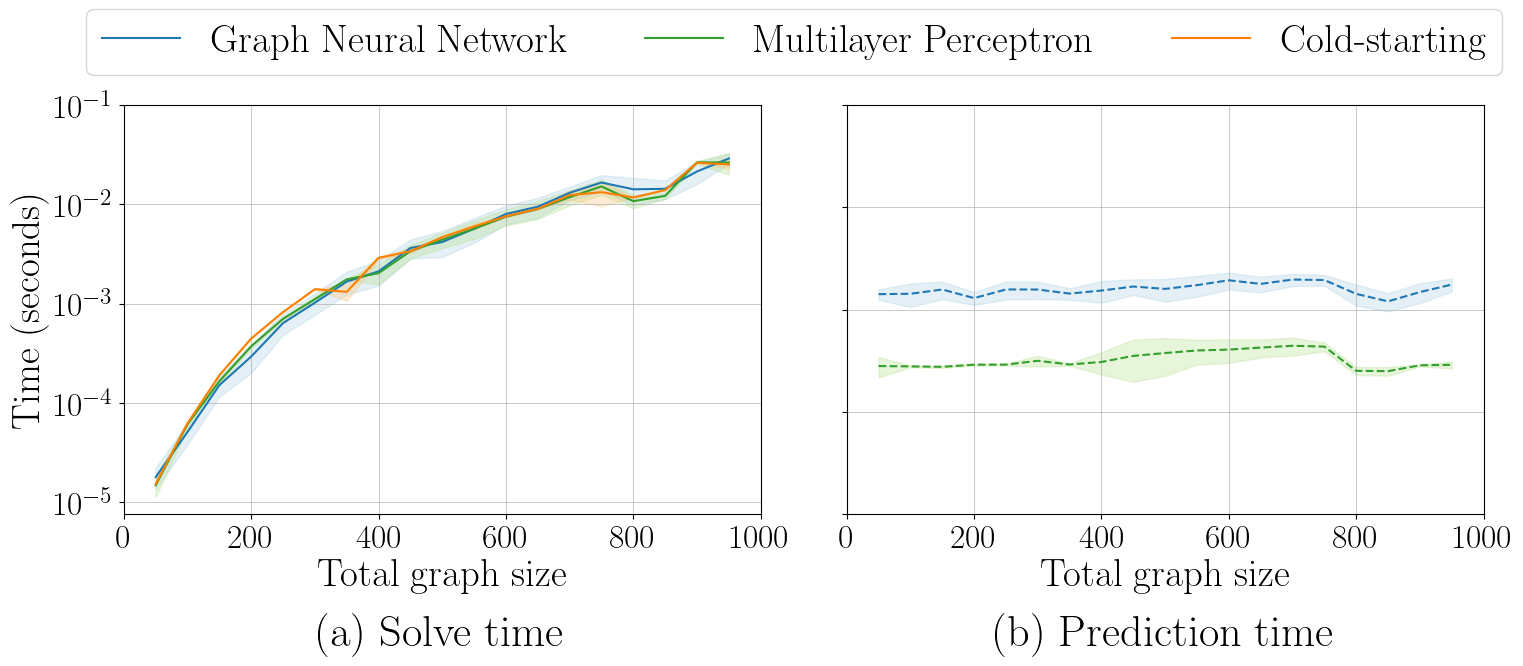

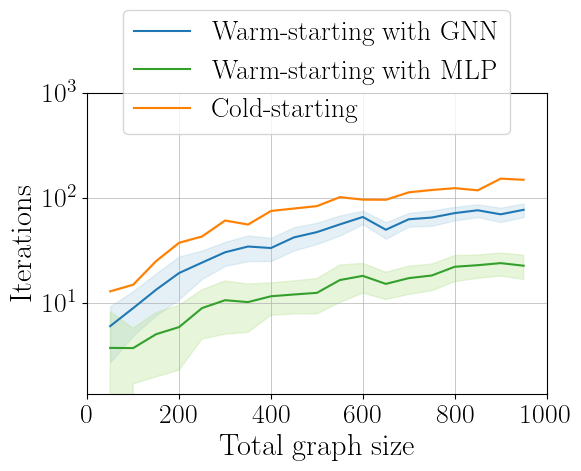

In [118]:
##### Figure 4: scaling of input QP size for GNN warm-starting #####

with open("./data/scaling_data_std_server_sparse.pkl", "rb") as f:
    points_loaded, labels_loaded,iterations_after_loaded = pickle.load(f)

#plot_scaling(points_loaded, labels_loaded,"plots/scaling_plot_std_test1",save = False)
plot_scaling_one_plot(points_loaded, labels_loaded,"plots/new/scaling_plot_std_one_plot", save=True)
plot_scaling_iterations(iterations_after_loaded, labels_loaded,"plots/new/scaling_plot_iterations_std", save=True)

max val: 387.0, min val: 185.8
max val: 0.0073013717999999995, min val: 0.004248529199999999


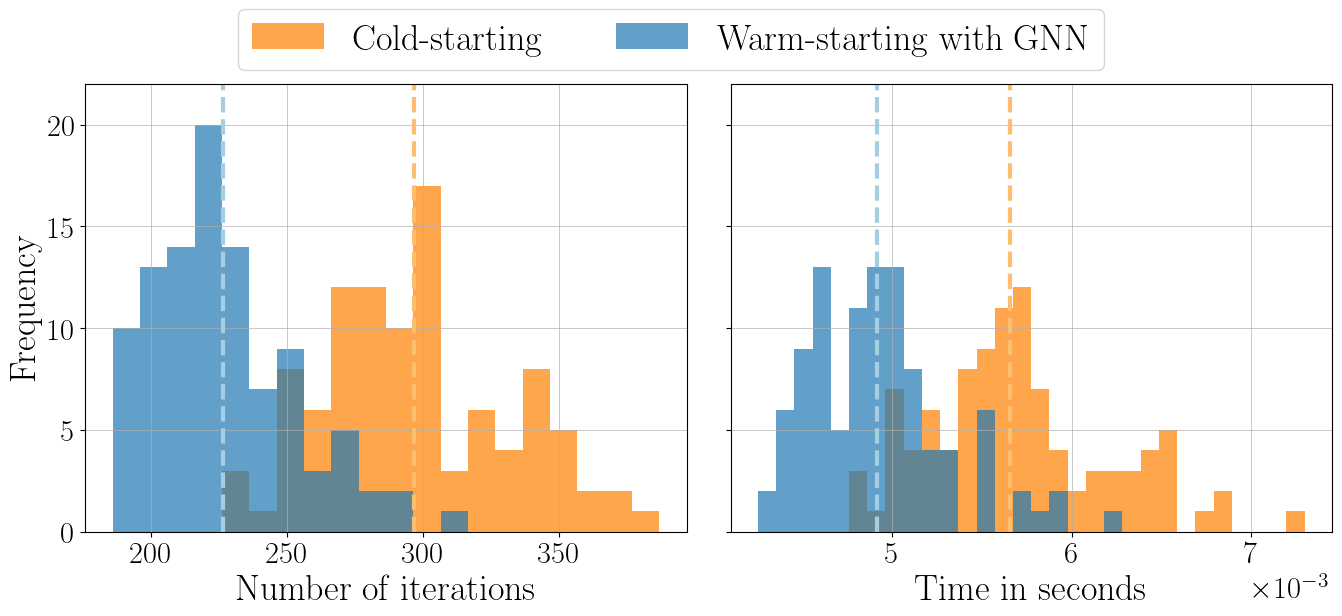

In [154]:
##### Figure 5 in the paper: histogram of iterations and solver time for scaling experiment #####

n_train = [20, 40, 60]
m_train = [40,80,120]
n_test = [100]
m_test = [200]
model_name = f"model_{n_train}v_{m_train}c_multi"

with open(f"data/multi_experiment_{n_train}v_{m_train}c_test_{n_test}v_{m_test}c.pkl", "rb") as f:
    parameters, test_time_before_avg,test_time_after_avg,test_iterations_before_avg,test_iterations_after_avg,test_iterations_diff_avg = pickle.load(f)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#fig, axes = plt.subplots(1, 2, figsize=(fig_width, subplot_height))

histogram_iterations(test_iterations_before_avg, test_iterations_after_avg, f"{model_name}_test", save=False, ax=axes[0],y_ax_limit=22)
histogram_time(test_time_before_avg, test_time_after_avg, f"{model_name}_test", save=False, ax=axes[1],y_ax_limit=22)

# Single shared legend, deduped
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(),
           loc='upper center', ncol=2, fontsize=26,
           bbox_to_anchor=(0.5, 1.09))
axes[1].set_ylabel('')
axes[1].set_yticklabels([])

plt.tight_layout()
plt.savefig(f"plots/new/histo_combined_{model_name}.pdf", bbox_inches='tight')
plt.show()

max val: 20.0, min val: 1.0
max val: 123.0, min val: 1.0


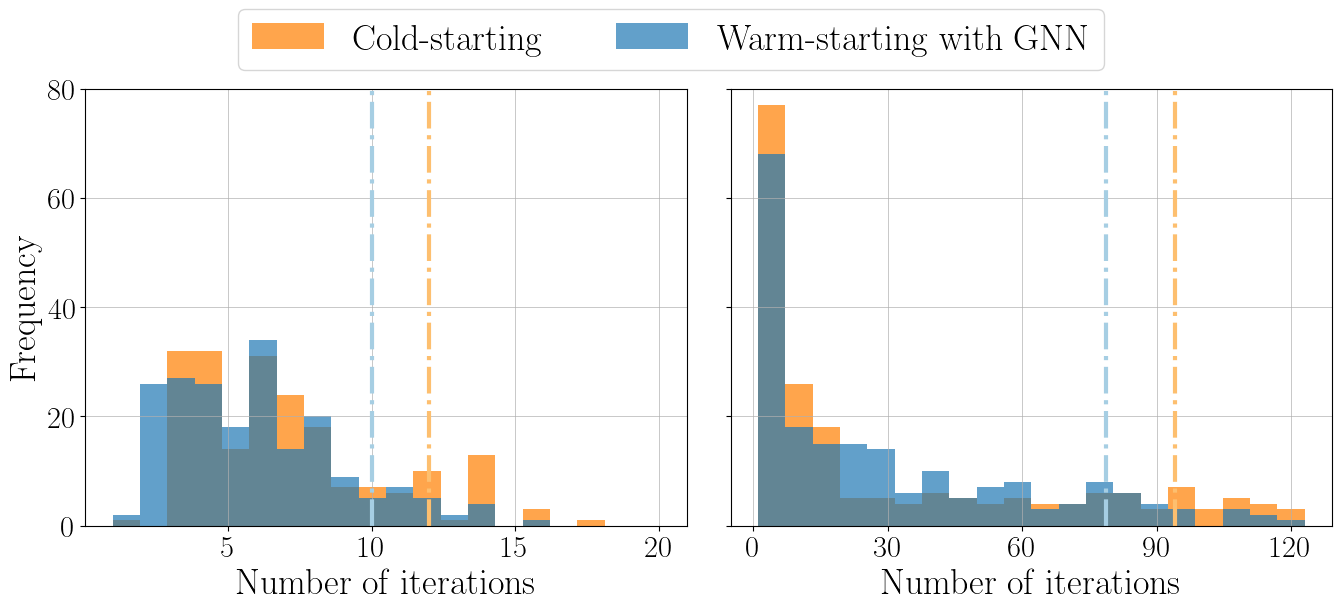

In [150]:
##### Figure 6 in paper: histogram of iterations before and after GNN warm-starting for 5v_206c and 50v_296c #####

# Set parameters
n = [5, 50]
m = [206, 296]
save = True

desired_ratio = 4 / 3          # width/height per subplot — adjust as needed
subplot_height = 6             # inches
subplot_width  = subplot_height * desired_ratio
fig_width = subplot_width * 2  # two subplots side by side

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

model_name = f"model_{n[0]}v_{m[0]}c_lmpc_R_00001_avg"
with open("./data/lmpc_experiment_5v_206c_server.pkl", "rb") as f:
    parameters, test_time_before_avg, test_time_after_avg, \
    test_iterations_before_avg, test_iterations_after_avg, \
    test_iterations_diff_avg = pickle.load(f)

histogram_iterations(test_iterations_before_avg, test_iterations_after_avg,
                     f"{model_name}_test", save=False, ax=axes[0],y_ax_limit=80,quantile=90)

model_name = f"model_{n[1]}v_{m[1]}c_lmpc_R_00001_avg"
with open("./data/lmpc_experiment_50v_296c_t_05.pkl", "rb") as f:
    parameters, test_time_before_avg, test_time_after_avg, \
    test_iterations_before_avg, test_iterations_after_avg, \
    test_iterations_diff_avg = pickle.load(f)

histogram_iterations(test_iterations_before_avg, test_iterations_after_avg,
                     f"{model_name}_test", save=False, ax=axes[1],y_ax_limit=80,quantile=90)

# Single shared legend, deduped
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(),
           loc='upper center', ncol=2, fontsize=26,
           bbox_to_anchor=(0.5, 1.08))

# Remove y-axis label from right subplot since sharey=True shares the axis
axes[1].set_ylabel('')

plt.tight_layout()
if save:
    plt.savefig(f"plots/new/histo_iter_lmpc_combined.pdf", bbox_inches='tight')
plt.show()


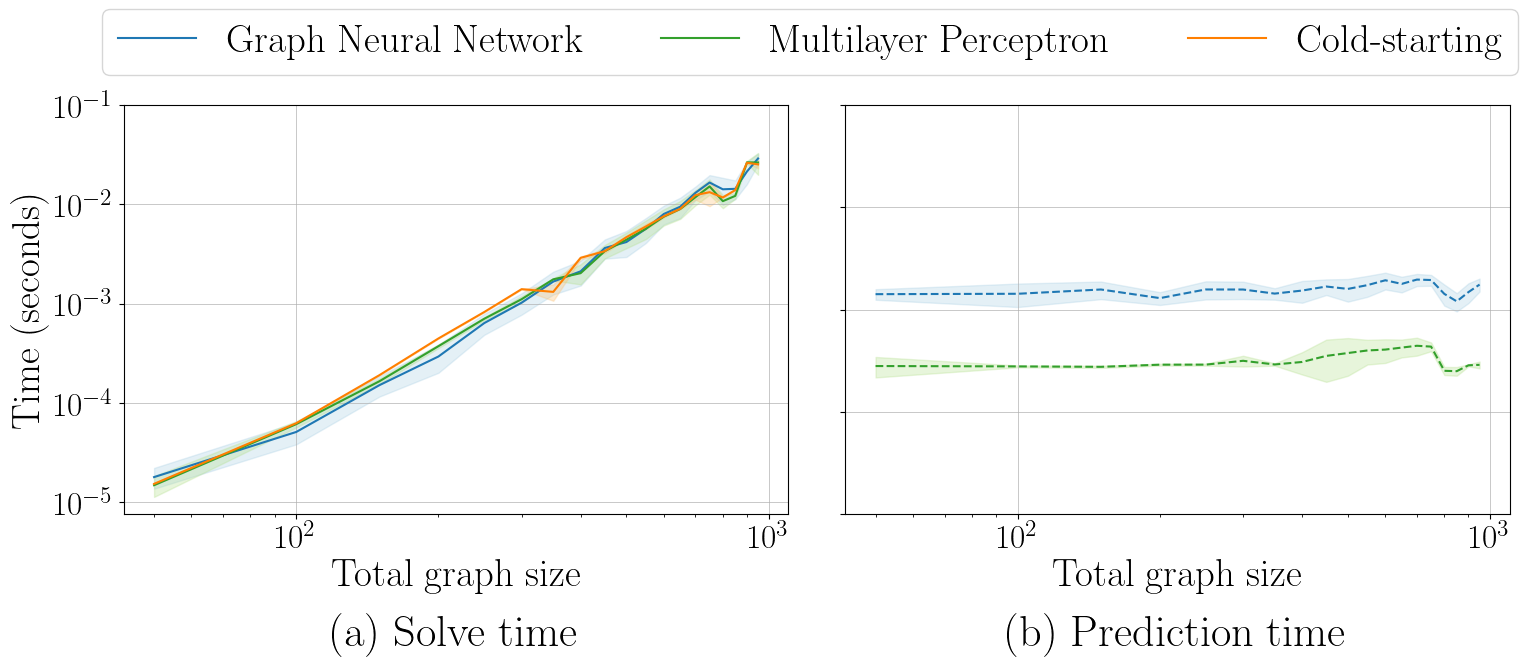

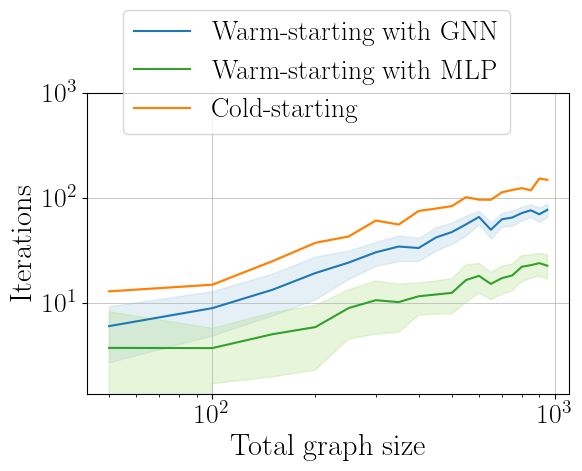

In [141]:
##### Figure 7+8: log-scaling of input QP size for GNN warm-starting #####

with open("./data/scaling_data_std_server_sparse.pkl", "rb") as f:
    points_loaded, labels_loaded,iterations_after_loaded = pickle.load(f)

#plot_scaling(points_loaded, labels_loaded,"plots/scaling_plot_std_test1",save = False)
plot_scaling_one_plot(points_loaded, labels_loaded,"plots/new/scaling_plot_std_log_log_one_plot", save=True)
plot_scaling_iterations(iterations_after_loaded, labels_loaded,"plots/new/scaling_plot_iterations_std_log_log", save=True)


max val: 2.9883800000000003e-05, min val: 9.2734e-06
max val: 0.0026216804, min val: 0.0005588673999999999


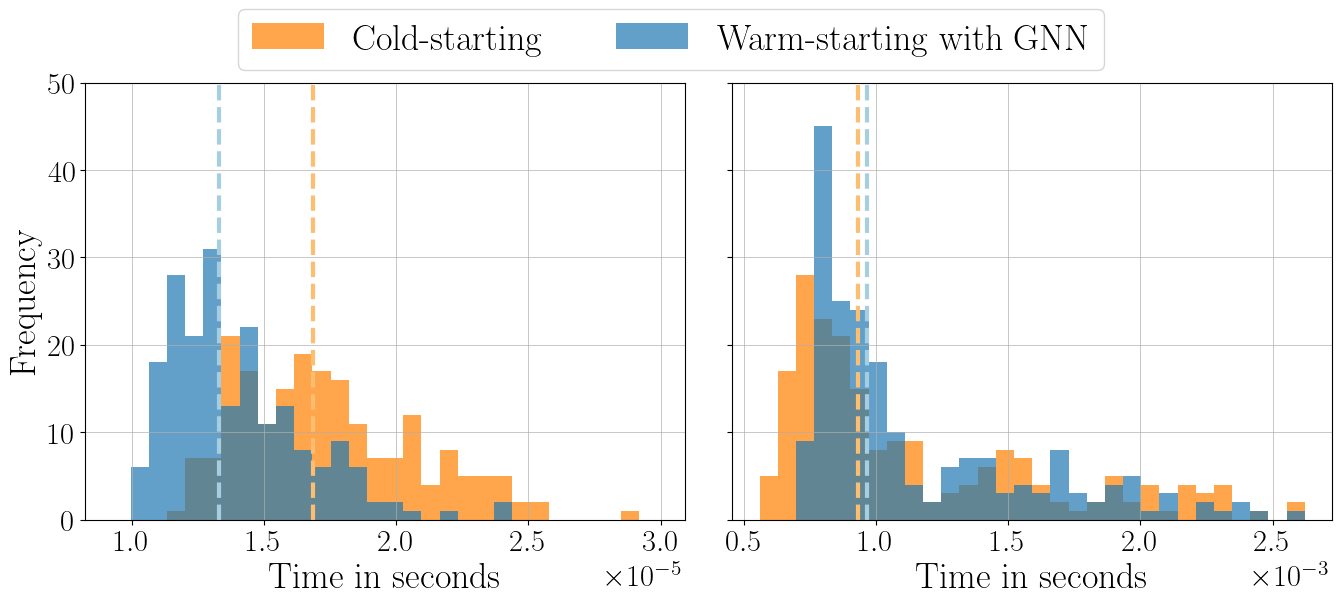

In [153]:
##### Figure 9: histogram of time before and after GNN warm-starting for 5v_206c and 50v_296c #####

# Set parameters
n = [5, 50]
m = [206, 296]
save = True

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
model_name = f"model_{n[0]}v_{m[0]}c_lmpc_R_00001_avg"
with open("./data/lmpc_experiment_5v_206c_server.pkl", "rb") as f:
    parameters, test_time_before_avg, test_time_after_avg, \
    test_iterations_before_avg, test_iterations_after_avg, \
    test_iterations_diff_avg = pickle.load(f)

histogram_time(test_time_before_avg, test_time_after_avg,
                     f"{model_name}_test", save=False, ax=axes[0],y_ax_limit=50)

model_name = f"model_{n[1]}v_{m[1]}c_lmpc_R_00001_avg"
with open("./data/lmpc_experiment_50v_296c_t_05.pkl", "rb") as f:
    parameters, test_time_before_avg, test_time_after_avg, \
    test_iterations_before_avg, test_iterations_after_avg, \
    test_iterations_diff_avg = pickle.load(f)

histogram_time(test_time_before_avg, test_time_after_avg,
                     f"{model_name}_test", save=False, ax=axes[1],y_ax_limit=50)

# Single shared legend, deduped
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(),
           loc='upper center', ncol=2, fontsize=26,
           bbox_to_anchor=(0.5, 1.07))

# Remove y-axis label from right subplot since sharey=True shares the axis
axes[1].set_ylabel('')

plt.tight_layout()
if save:
    plt.savefig(f"plots/new/histo_time_lmpc_combined.pdf", bbox_inches='tight')
plt.show()